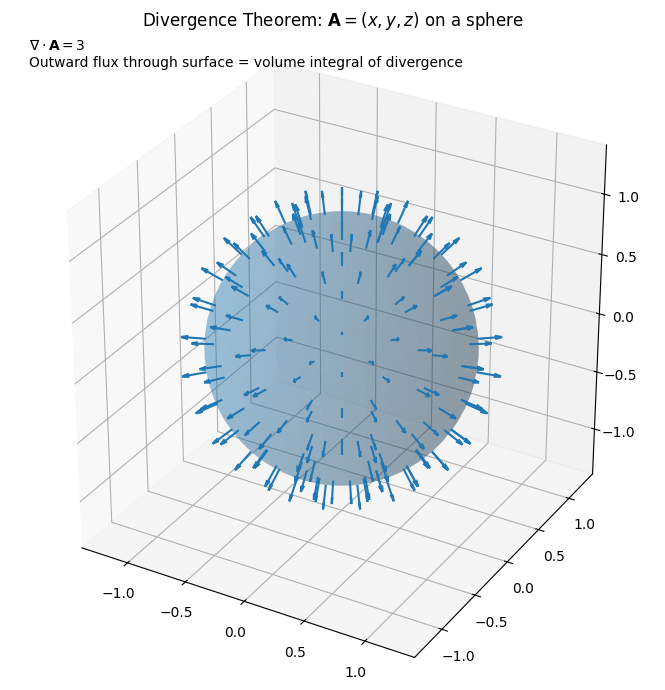

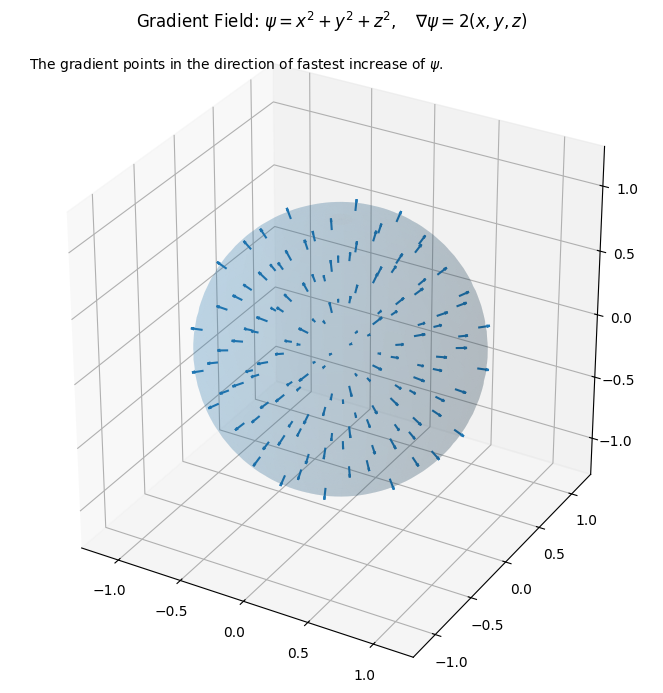

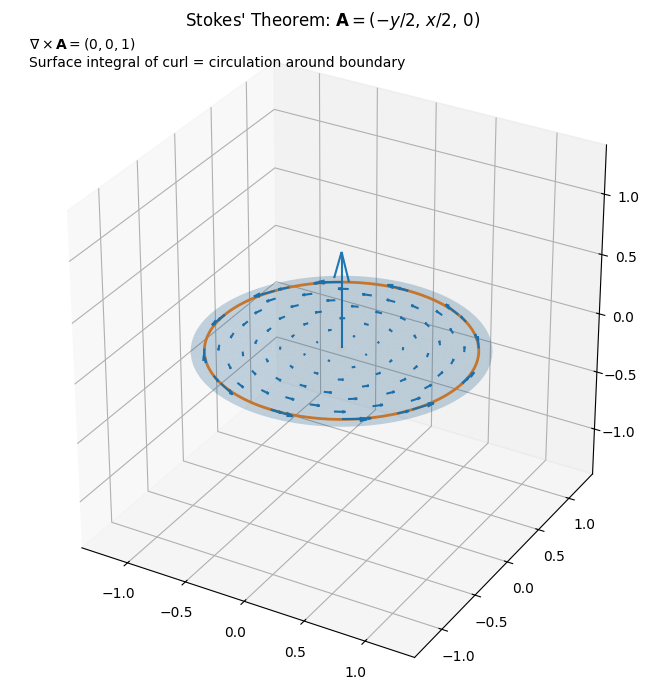

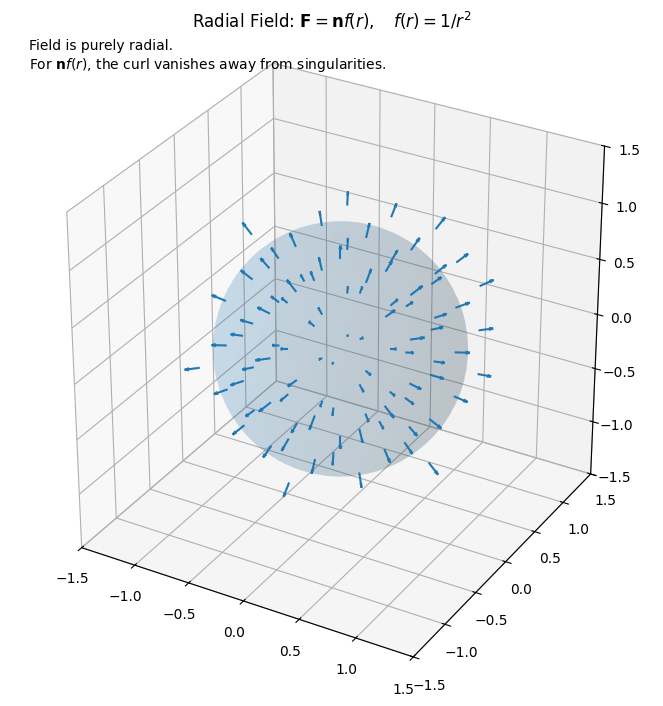

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# =========================
# Helper functions
# =========================

def sphere_mesh(radius=1.0, n_theta=40, n_phi=80):
    theta = np.linspace(0, np.pi, n_theta)
    phi = np.linspace(0, 2*np.pi, n_phi)
    theta, phi = np.meshgrid(theta, phi)

    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    return x, y, z


def disk_mesh(radius=1.2, n_r=25, n_t=80, z0=0.0):
    r = np.linspace(0, radius, n_r)
    t = np.linspace(0, 2*np.pi, n_t)
    r, t = np.meshgrid(r, t)

    x = r * np.cos(t)
    y = r * np.sin(t)
    z = np.full_like(x, z0)
    return x, y, z


def set_equal_3d(ax, lim=1.5):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_box_aspect([1, 1, 1])


# =========================
# 1. Divergence theorem
# Field: A = (x, y, z)
# div A = 3
# =========================

def plot_divergence_theorem():
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Sphere
    xs, ys, zs = sphere_mesh(radius=1.0)
    ax.plot_surface(xs, ys, zs, alpha=0.25, edgecolor='none')

    # Sample points on sphere
    theta = np.linspace(0.3, np.pi - 0.3, 10)
    phi = np.linspace(0, 2*np.pi, 16)
    theta, phi = np.meshgrid(theta, phi)

    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)

    # A = (x,y,z), same as outward normal on unit sphere
    u = x
    v = y
    w = z

    ax.quiver(x, y, z, u, v, w, length=0.18, normalize=True)

    ax.set_title(r"Divergence Theorem: $\mathbf{A}=(x,y,z)$ on a sphere")
    ax.text2D(
        0.03, 0.95,
        r"$\nabla\cdot\mathbf{A}=3$"
        "\n"
        r"Outward flux through surface = volume integral of divergence",
        transform=ax.transAxes
    )

    set_equal_3d(ax, 1.4)
    plt.tight_layout()
    plt.show()


# =========================
# 2. Gradient theorem picture
# psi = x^2 + y^2 + z^2
# grad psi = 2(x,y,z)
# =========================

def plot_gradient_field():
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Show a semi-transparent sphere
    xs, ys, zs = sphere_mesh(radius=1.0)
    ax.plot_surface(xs, ys, zs, alpha=0.15, edgecolor='none')

    # Sample grid in a cube
    pts = np.linspace(-0.8, 0.8, 6)
    X, Y, Z = np.meshgrid(pts, pts, pts)

    # Remove points too close to origin and outside sphere-ish region
    R = np.sqrt(X**2 + Y**2 + Z**2)
    mask = (R > 0.25) & (R < 0.95)

    Xp = X[mask]
    Yp = Y[mask]
    Zp = Z[mask]

    # grad psi = 2(x,y,z)
    U = 2 * Xp
    V = 2 * Yp
    W = 2 * Zp

    ax.quiver(Xp, Yp, Zp, U, V, W, length=0.08, normalize=True)

    ax.set_title(r"Gradient Field: $\psi=x^2+y^2+z^2,\quad \nabla\psi=2(x,y,z)$")
    ax.text2D(
        0.03, 0.95,
        r"The gradient points in the direction of fastest increase of $\psi$.",
        transform=ax.transAxes
    )

    set_equal_3d(ax, 1.3)
    plt.tight_layout()
    plt.show()


# =========================
# 3. Stokes theorem
# A = (-y/2, x/2, 0)
# curl A = (0,0,1)
# =========================

def plot_stokes_theorem():
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Disk surface in z=0 plane
    xd, yd, zd = disk_mesh(radius=1.1, z0=0.0)
    ax.plot_surface(xd, yd, zd, alpha=0.25, edgecolor='none')

    # Vector field on disk
    pts = np.linspace(-1.0, 1.0, 11)
    X, Y = np.meshgrid(pts, pts)
    Z = np.zeros_like(X)
    R = np.sqrt(X**2 + Y**2)
    mask = R <= 1.0

    Xp = X[mask]
    Yp = Y[mask]
    Zp = Z[mask]

    U = -Yp / 2
    V = Xp / 2
    W = np.zeros_like(U)

    ax.quiver(Xp, Yp, Zp, U, V, W, length=0.18, normalize=False)

    # Boundary circle
    t = np.linspace(0, 2*np.pi, 300)
    xc = np.cos(t)
    yc = np.sin(t)
    zc = np.zeros_like(t)
    ax.plot(xc, yc, zc, linewidth=2)

    # A few tangent arrows along boundary
    sample_t = np.linspace(0, 2*np.pi, 12, endpoint=False)
    xb = np.cos(sample_t)
    yb = np.sin(sample_t)
    zb = np.zeros_like(sample_t)

    # Tangent direction for positively oriented boundary
    tx = -np.sin(sample_t)
    ty = np.cos(sample_t)
    tz = np.zeros_like(sample_t)

    ax.quiver(xb, yb, zb, tx, ty, tz, length=0.18, normalize=True)

    # Normal vector
    ax.quiver(0, 0, 0, 0, 0, 1, length=0.8, normalize=True)

    ax.set_title(r"Stokes' Theorem: $\mathbf{A}=(-y/2,\,x/2,\,0)$")
    ax.text2D(
        0.03, 0.95,
        r"$\nabla\times\mathbf{A}=(0,0,1)$"
        "\n"
        r"Surface integral of curl = circulation around boundary",
        transform=ax.transAxes
    )

    set_equal_3d(ax, 1.4)
    plt.tight_layout()
    plt.show()


# =========================
# 4. Curl-free radial field
# F = n f(r), choose f(r)=1/r^2  (avoid origin)
# F = r / r^3
# =========================

def plot_radial_field():
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    pts = np.linspace(-1.2, 1.2, 7)
    X, Y, Z = np.meshgrid(pts, pts, pts)
    R = np.sqrt(X**2 + Y**2 + Z**2)

    mask = (R > 0.45) & (R < 1.2)

    Xp = X[mask]
    Yp = Y[mask]
    Zp = Z[mask]
    Rp = R[mask]

    # Radial field F = x / r^3
    U = Xp / (Rp**3)
    V = Yp / (Rp**3)
    W = Zp / (Rp**3)

    ax.quiver(Xp, Yp, Zp, U, V, W, length=0.12, normalize=True)

    xs, ys, zs = sphere_mesh(radius=1.0)
    ax.plot_surface(xs, ys, zs, alpha=0.12, edgecolor='none')

    ax.set_title(r"Radial Field: $\mathbf{F}=\mathbf{n}f(r),\quad f(r)=1/r^2$")
    ax.text2D(
        0.03, 0.95,
        r"Field is purely radial."
        "\n"
        r"For $\mathbf{n}f(r)$, the curl vanishes away from singularities.",
        transform=ax.transAxes
    )

    set_equal_3d(ax, 1.5)
    plt.tight_layout()
    plt.show()


# =========================
# Run all
# =========================

if __name__ == "__main__":
    plot_divergence_theorem()
    plot_gradient_field()
    plot_stokes_theorem()
    plot_radial_field()


1) Divergence theorem
---------------------
LHS = 12.566370614359
RHS = 12.566155117163
Difference = 2.154971958035e-04


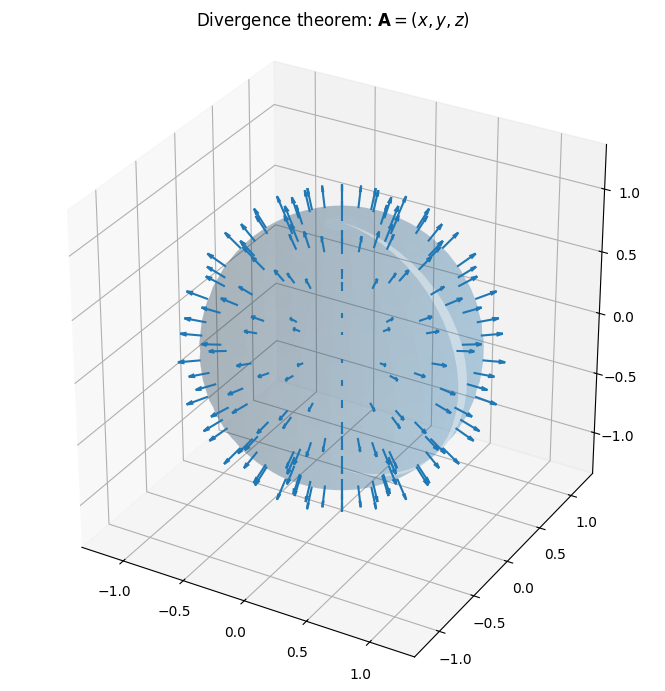


2) Volume integral of gradient identity
---------------------------------------
LHS = [0. 0. 0.]
RHS = [-8.91864707e-16  1.21430643e-17  2.49800181e-16]
Difference = [ 8.91864707e-16 -1.21430643e-17 -2.49800181e-16]


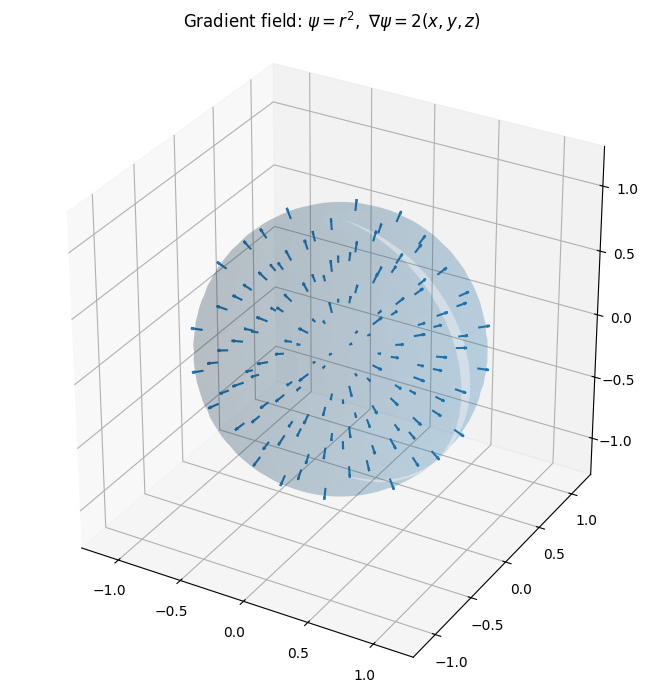


3) Volume integral of curl identity
-----------------------------------
LHS = [0.        0.        4.1887902]
RHS = [-1.02999206e-18  2.81892565e-18  4.18879021e+00]
Difference = [ 1.02999206e-18 -2.81892565e-18 -2.21739516e-09]


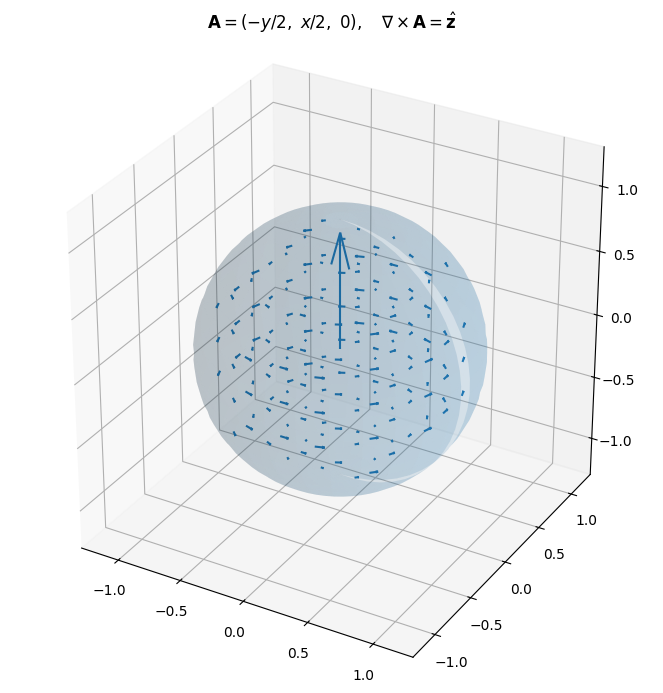


4) Stokes theorem
-----------------
LHS = 3.141592653590
RHS = 3.141592653590
Difference = -4.440892098501e-16


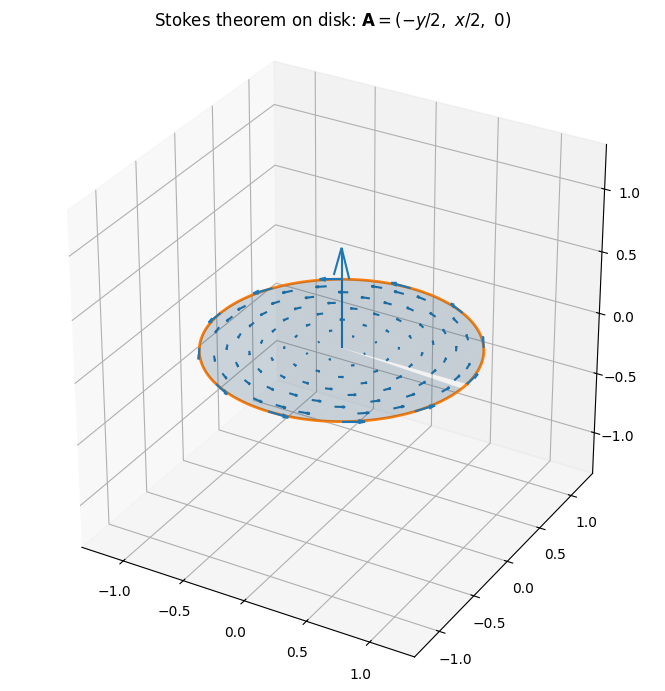


5) Radial identities
--------------------
Mean numerical divergence for F=x: 3.000000000000   (expected 3)
Max numerical curl magnitude for F=x: 0.000000000000e+00   (expected 0)


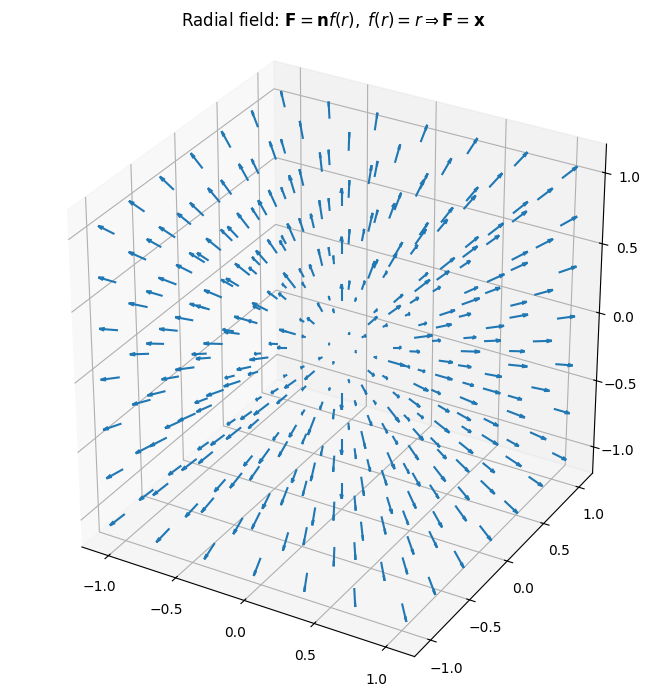

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# NUMERICAL + VISUAL VERIFICATION OF VECTOR CALCULUS THEOREMS
# ============================================================
#
# The script verifies and plots:
#
# 1) Divergence theorem
#    ∭_V (∇·A) dV = ∬_S A·n dS
#
# 2) Gradient surface identity
#    ∭_V ∇ψ dV = ∬_S ψ n dS
#
# 3) Volume integral of curl identity
#    ∭_V (∇×A) dV = ∬_S (n×A) dS
#
# 4) Stokes theorem
#    ∬_S (∇×A)·n dS = ∮_C A·dl
#
# 5) Radial identities:
#    div[n f(r)] = 2 f(r)/r + df/dr
#    curl[n f(r)] = 0
#
# It uses simple geometries:
# - sphere for volume/surface integrals
# - disk for Stokes theorem
#
# ============================================================


# -------------------------------
# Utilities
# -------------------------------

def set_equal_axes_3d(ax, lim=1.5):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_box_aspect([1, 1, 1])


def sphere_surface_grid(R=1.0, n_theta=120, n_phi=240):
    theta = np.linspace(0.0, np.pi, n_theta)
    phi = np.linspace(0.0, 2.0*np.pi, n_phi, endpoint=False)
    theta, phi = np.meshgrid(theta, phi, indexing="ij")

    x = R * np.sin(theta) * np.cos(phi)
    y = R * np.sin(theta) * np.sin(phi)
    z = R * np.cos(theta)

    return x, y, z, theta, phi


def sphere_surface_integral_scalar(func, R=1.0, n_theta=220, n_phi=440):
    x, y, z, theta, phi = sphere_surface_grid(R, n_theta, n_phi)
    dtheta = np.pi / (n_theta - 1)
    dphi = 2.0*np.pi / n_phi

    vals = func(x, y, z)

    dS = (R**2) * np.sin(theta) * dtheta * dphi
    return np.sum(vals * dS)


def sphere_surface_integral_vector(func, R=1.0, n_theta=220, n_phi=440):
    x, y, z, theta, phi = sphere_surface_grid(R, n_theta, n_phi)
    dtheta = np.pi / (n_theta - 1)
    dphi = 2.0*np.pi / n_phi

    Fx, Fy, Fz = func(x, y, z)
    dS = (R**2) * np.sin(theta) * dtheta * dphi

    Ix = np.sum(Fx * dS)
    Iy = np.sum(Fy * dS)
    Iz = np.sum(Fz * dS)
    return np.array([Ix, Iy, Iz], dtype=float)


def disk_polar_grid(a=1.0, n_r=250, n_t=500):
    r = np.linspace(0.0, a, n_r)
    t = np.linspace(0.0, 2.0*np.pi, n_t, endpoint=False)
    rr, tt = np.meshgrid(r, t, indexing="ij")

    x = rr * np.cos(tt)
    y = rr * np.sin(tt)
    return x, y, rr, tt


# -------------------------------
# Theorem 1: Divergence theorem
# Choose A = (x, y, z)
# div A = 3
# Sphere radius R
#
# Volume side:
#   ∭_V 3 dV = 3 * 4πR^3/3 = 4πR^3
#
# Surface side:
#   On sphere n = x/R, A·n = R
#   ∬_S R dS = R * 4πR^2 = 4πR^3
# -------------------------------

def verify_divergence_theorem(R=1.0):
    lhs = 4.0 * np.pi * R**3

    def surface_flux(x, y, z):
        n_x = x / R
        n_y = y / R
        n_z = z / R
        A_dot_n = x*n_x + y*n_y + z*n_z
        return A_dot_n

    rhs = sphere_surface_integral_scalar(surface_flux, R=R)
    return lhs, rhs


def plot_divergence_theorem(R=1.0):
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection="3d")

    x, y, z, theta, phi = sphere_surface_grid(R, 28, 56)
    ax.plot_surface(x, y, z, alpha=0.18)

    theta_q = np.linspace(0.35, np.pi - 0.35, 9)
    phi_q = np.linspace(0.0, 2*np.pi, 18, endpoint=False)
    TQ, PQ = np.meshgrid(theta_q, phi_q, indexing="ij")

    X = R * np.sin(TQ) * np.cos(PQ)
    Y = R * np.sin(TQ) * np.sin(PQ)
    Z = R * np.cos(TQ)

    U = X
    V = Y
    W = Z

    ax.quiver(X, Y, Z, U, V, W, length=0.16, normalize=True)
    ax.set_title(r"Divergence theorem: $\mathbf{A}=(x,y,z)$")
    set_equal_axes_3d(ax, lim=1.35*R)
    plt.tight_layout()
    plt.show()


# -------------------------------
# Theorem 2: ∭_V ∇ψ dV = ∬_S ψ n dS
# Choose ψ = x^2 + y^2 + z^2 = r^2
# Then ∇ψ = 2(x,y,z)
#
# On a sphere of radius R:
# Volume side = ∭ 2(x,y,z) dV = (0,0,0) by symmetry
# Surface side = ∬ R^2 n dS = R^2 ∬ n dS = 0 by symmetry
# -------------------------------

def verify_gradient_surface_identity(R=1.0):
    lhs = np.array([0.0, 0.0, 0.0])

    def surface_vec(x, y, z):
        psi = x**2 + y**2 + z**2
        n_x = x / R
        n_y = y / R
        n_z = z / R
        return psi * n_x, psi * n_y, psi * n_z

    rhs = sphere_surface_integral_vector(surface_vec, R=R)
    return lhs, rhs


def plot_gradient_identity(R=1.0):
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection="3d")

    x, y, z, *_ = sphere_surface_grid(R, 28, 56)
    ax.plot_surface(x, y, z, alpha=0.15)

    vals = np.linspace(-0.8*R, 0.8*R, 6)
    X, Y, Z = np.meshgrid(vals, vals, vals, indexing="ij")
    RR = np.sqrt(X**2 + Y**2 + Z**2)
    mask = (RR > 0.2*R) & (RR < 0.95*R)

    Xp = X[mask]
    Yp = Y[mask]
    Zp = Z[mask]

    U = 2.0 * Xp
    V = 2.0 * Yp
    W = 2.0 * Zp

    ax.quiver(Xp, Yp, Zp, U, V, W, length=0.08*R, normalize=True)
    ax.set_title(r"Gradient field: $\psi=r^2,\ \nabla\psi=2(x,y,z)$")
    set_equal_axes_3d(ax, lim=1.3*R)
    plt.tight_layout()
    plt.show()


# -------------------------------
# Theorem 3: ∭_V (∇×A) dV = ∬_S (n×A) dS
# Choose A = (-y/2, x/2, 0)
# curl A = (0,0,1)
#
# Sphere:
# Volume side = (0,0, Volume) = (0,0, 4πR^3/3)
#
# Surface side computed numerically.
# -------------------------------

def verify_volume_integral_curl_identity(R=1.0):
    volume = (4.0/3.0) * np.pi * R**3
    lhs = np.array([0.0, 0.0, volume])

    def surface_vec(x, y, z):
        n_x = x / R
        n_y = y / R
        n_z = z / R

        A_x = -0.5 * y
        A_y =  0.5 * x
        A_z = np.zeros_like(z)

        cross_x = n_y*A_z - n_z*A_y
        cross_y = n_z*A_x - n_x*A_z
        cross_z = n_x*A_y - n_y*A_x

        return cross_x, cross_y, cross_z

    rhs = sphere_surface_integral_vector(surface_vec, R=R)
    return lhs, rhs


def plot_curl_identity(R=1.0):
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection="3d")

    x, y, z, *_ = sphere_surface_grid(R, 28, 56)
    ax.plot_surface(x, y, z, alpha=0.14)

    vals = np.linspace(-0.8*R, 0.8*R, 7)
    X, Y, Z = np.meshgrid(vals, vals, vals, indexing="ij")
    RR = np.sqrt(X**2 + Y**2 + Z**2)
    mask = RR < 0.95*R

    Xp = X[mask]
    Yp = Y[mask]
    Zp = Z[mask]

    U = -0.5 * Yp
    V =  0.5 * Xp
    W = np.zeros_like(Zp)

    ax.quiver(Xp, Yp, Zp, U, V, W, length=0.16*R, normalize=False)
    ax.quiver(0, 0, 0, 0, 0, 1, length=0.9*R, normalize=True)

    ax.set_title(r"$\mathbf{A}=(-y/2,\ x/2,\ 0),\quad \nabla\times\mathbf{A}=\hat{\mathbf{z}}$")
    set_equal_axes_3d(ax, lim=1.3*R)
    plt.tight_layout()
    plt.show()


# -------------------------------
# Theorem 4: Stokes theorem on disk z=0, radius a
# Choose A = (-y/2, x/2, 0), so curl A = (0,0,1)
#
# Surface side:
#   ∬_S (curl A)·n dS = ∬_disk 1 dS = π a^2
#
# Line side:
#   boundary C: x=a cos t, y=a sin t
#   A·dl = a^2/2 dt
#   integral = π a^2
# -------------------------------

def verify_stokes_theorem(a=1.0, n_t=100000):
    lhs = np.pi * a**2

    t = np.linspace(0.0, 2.0*np.pi, n_t, endpoint=False)
    dt = 2.0*np.pi / n_t

    x = a * np.cos(t)
    y = a * np.sin(t)

    dx = -a * np.sin(t) * dt
    dy =  a * np.cos(t) * dt

    A_x = -0.5 * y
    A_y =  0.5 * x

    rhs = np.sum(A_x * dx + A_y * dy)
    return lhs, rhs


def plot_stokes_theorem(a=1.0):
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection="3d")

    x, y, rr, tt = disk_polar_grid(a=a, n_r=35, n_t=90)
    z = np.zeros_like(x)
    ax.plot_surface(x, y, z, alpha=0.2)

    vals = np.linspace(-0.9*a, 0.9*a, 11)
    X, Y = np.meshgrid(vals, vals, indexing="ij")
    Z = np.zeros_like(X)
    RR = np.sqrt(X**2 + Y**2)
    mask = RR <= 0.95*a

    Xp = X[mask]
    Yp = Y[mask]
    Zp = Z[mask]

    U = -0.5 * Yp
    V =  0.5 * Xp
    W = np.zeros_like(U)

    ax.quiver(Xp, Yp, Zp, U, V, W, length=0.18*a, normalize=False)

    t = np.linspace(0.0, 2*np.pi, 400)
    xb = a * np.cos(t)
    yb = a * np.sin(t)
    zb = np.zeros_like(t)
    ax.plot(xb, yb, zb, linewidth=2)

    ts = np.linspace(0.0, 2*np.pi, 12, endpoint=False)
    xs = a * np.cos(ts)
    ys = a * np.sin(ts)
    zs = np.zeros_like(ts)

    tx = -np.sin(ts)
    ty =  np.cos(ts)
    tz = np.zeros_like(ts)
    ax.quiver(xs, ys, zs, tx, ty, tz, length=0.16*a, normalize=True)

    ax.quiver(0, 0, 0, 0, 0, 1, length=0.8*a, normalize=True)

    ax.set_title(r"Stokes theorem on disk: $\mathbf{A}=(-y/2,\ x/2,\ 0)$")
    set_equal_axes_3d(ax, lim=1.35*a)
    plt.tight_layout()
    plt.show()


# -------------------------------
# Theorem 5: Radial identities
# F = n f(r), choose f(r)=r
# Then F = n r = x
#
# So:
#   div(F)=3
#   2f/r + df/dr = 2r/r + 1 = 3
#   curl(F)=0
#
# We compare numerical finite differences on a 3D grid.
# -------------------------------

def verify_radial_identities(box=1.0, N=41):
    x = np.linspace(-box, box, N)
    y = np.linspace(-box, box, N)
    z = np.linspace(-box, box, N)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    dz = z[1] - z[0]

    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    R = np.sqrt(X**2 + Y**2 + Z**2)

    # Choose f(r)=r => n f(r)=x vector field
    Fx = X.copy()
    Fy = Y.copy()
    Fz = Z.copy()

    dFx_dx = np.gradient(Fx, dx, axis=0)
    dFy_dy = np.gradient(Fy, dy, axis=1)
    dFz_dz = np.gradient(Fz, dz, axis=2)

    div_num = dFx_dx + dFy_dy + dFz_dz

    dFz_dy = np.gradient(Fz, dy, axis=1)
    dFy_dz = np.gradient(Fy, dz, axis=2)

    dFx_dz = np.gradient(Fx, dz, axis=2)
    dFz_dx = np.gradient(Fz, dx, axis=0)

    dFy_dx = np.gradient(Fy, dx, axis=0)
    dFx_dy = np.gradient(Fx, dy, axis=1)

    curl_x = dFz_dy - dFy_dz
    curl_y = dFx_dz - dFz_dx
    curl_z = dFy_dx - dFx_dy

    # avoid boundary noise
    sl = slice(3, -3)
    div_core = div_num[sl, sl, sl]
    curl_mag_core = np.sqrt(curl_x[sl, sl, sl]**2 + curl_y[sl, sl, sl]**2 + curl_z[sl, sl, sl]**2)

    div_mean = np.mean(div_core)
    curl_max = np.max(np.abs(curl_mag_core))

    return div_mean, curl_max


def plot_radial_field(box=1.0):
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection="3d")

    vals = np.linspace(-box, box, 7)
    X, Y, Z = np.meshgrid(vals, vals, vals, indexing="ij")
    R = np.sqrt(X**2 + Y**2 + Z**2)
    mask = R > 0.25*box

    Xp = X[mask]
    Yp = Y[mask]
    Zp = Z[mask]

    # F = x
    U = Xp
    V = Yp
    W = Zp

    ax.quiver(Xp, Yp, Zp, U, V, W, length=0.12*box, normalize=True)
    ax.set_title(r"Radial field: $\mathbf{F}=\mathbf{n}f(r),\ f(r)=r \Rightarrow \mathbf{F}=\mathbf{x}$")
    set_equal_axes_3d(ax, lim=1.2*box)
    plt.tight_layout()
    plt.show()


# -------------------------------
# Print results nicely
# -------------------------------

def print_vector_result(name, lhs, rhs):
    print(f"\n{name}")
    print("-" * len(name))
    print("LHS =", lhs)
    print("RHS =", rhs)
    print("Difference =", np.array(lhs) - np.array(rhs))


def print_scalar_result(name, lhs, rhs):
    print(f"\n{name}")
    print("-" * len(name))
    print(f"LHS = {lhs:.12f}")
    print(f"RHS = {rhs:.12f}")
    print(f"Difference = {lhs - rhs:.12e}")


# -------------------------------
# Main
# -------------------------------

if __name__ == "__main__":
    # 1. Divergence theorem
    lhs1, rhs1 = verify_divergence_theorem(R=1.0)
    print_scalar_result("1) Divergence theorem", lhs1, rhs1)
    plot_divergence_theorem(R=1.0)

    # 2. Gradient identity
    lhs2, rhs2 = verify_gradient_surface_identity(R=1.0)
    print_vector_result("2) Volume integral of gradient identity", lhs2, rhs2)
    plot_gradient_identity(R=1.0)

    # 3. Volume integral of curl identity
    lhs3, rhs3 = verify_volume_integral_curl_identity(R=1.0)
    print_vector_result("3) Volume integral of curl identity", lhs3, rhs3)
    plot_curl_identity(R=1.0)

    # 4. Stokes theorem
    lhs4, rhs4 = verify_stokes_theorem(a=1.0, n_t=200000)
    print_scalar_result("4) Stokes theorem", lhs4, rhs4)
    plot_stokes_theorem(a=1.0)

    # 5. Radial identities
    div_mean, curl_max = verify_radial_identities(box=1.0, N=41)
    print("\n5) Radial identities")
    print("--------------------")
    print(f"Mean numerical divergence for F=x: {div_mean:.12f}   (expected 3)")
    print(f"Max numerical curl magnitude for F=x: {curl_max:.12e}   (expected 0)")
    plot_radial_field(box=1.0)